## Lagrange Interpolation in Newton Form

Given distinct nodes $x_0, x_1, \dots, x_n$ and values $f(x_i)$, the interpolation polynomial can be written in **Newton form**:

$$
P_n(x)=f[x_0]
+f[x_0,x_1](x-x_0)
+f[x_0,x_1,x_2](x-x_0)(x-x_1)
+\cdots
+f[x_0,\dots,x_n]\prod_{j=0}^{n-1}(x-x_j).
$$

where $f[x_i,\dots,x_{i+k}]$ are divided differences:

$$
f[x_i]=f(x_i), \qquad
f[x_i,\dots,x_{i+k}]=\frac{f[x_{i+1},\dots,x_{i+k}]-f[x_i,\dots,x_{i+k-1}]}{x_{i+k}-x_i}.
$$

The interpolation error (remainder) is:

$$
R_n(x)=f(x)-P_n(x)=\frac{f^{(n+1)}(\xi_x)}{(n+1)!}\prod_{i=0}^{n}(x-x_i),
\qquad \xi_x\in(\min x_i,\max x_i).
$$

So a practical bound is

$$
|R_n(x)|\le \frac{M_{n+1}}{(n+1)!}\left|\prod_{i=0}^{n}(x-x_i)\right|,
$$

with $M_{n+1}\ge \max_{t\in[a,b]}|f^{(n+1)}(t)|$. For interval bounds on $[a,b]$, also bound
$\max_{x\in[a,b]}\left|\prod_{i=0}^{n}(x-x_i)\right|$.

The code cell below implements these formulas so each exercise step can be done by plugging in $f$, nodes, and interval settings.

In [39]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def divided_differences_table(nodes, f=None, values=None):
    """
    Build divided differences table for distinct nodes.

    Parameters:
    - nodes: interpolation nodes x_i
    - f: callable function f(x) (optional if values is provided)
    - values: list/array of f(x_i) values (optional if f is provided)

    Returns:
    - pandas.DataFrame with columns x, f(x), order_1, ..., order_{n-1}
    """
    nodes = np.asarray(nodes, dtype=float)
    n = len(nodes)

    if n == 0:
        raise ValueError("'nodes' must contain at least one element.")
    if len(np.unique(nodes)) != n:
        raise ValueError("All interpolation nodes must be distinct.")

    if values is not None and len(values) != n:
        raise ValueError("'values' must have the same length as 'nodes'.")
    if f is None and values is None:
        raise ValueError("Provide either a function 'f' or a list/array 'values'.")

    table = np.zeros((n, n + 1), dtype=float)
    table[:, 0] = nodes

    if values is not None:
        table[:, 1] = np.asarray(values, dtype=float)
    else:
        table[:, 1] = np.array([f(x) for x in nodes], dtype=float)

    # table[i, j] stores f[x_i, ..., x_{i + j - 1}] for j >= 1
    for j in range(2, n + 1):
        for i in range(n - j + 1):
            numerator = table[i + 1, j - 1] - table[i, j - 1]
            denominator = nodes[i + j - 1] - nodes[i]
            table[i, j] = numerator / denominator

    columns = ["x", "f(x)"] + [f"order_{k}" for k in range(1, n)]
    return pd.DataFrame(table, columns=columns)


def newton_coefficients(nodes, f=None, values=None):
    """
    Return Newton coefficients a_k = f[x_0, ..., x_k].
    """
    dd = divided_differences_table(nodes, f=f, values=values)
    n = len(nodes)
    return np.array([dd.iloc[0, k + 1] for k in range(n)], dtype=float)


def newton_eval(x, nodes, coeffs):
    """
    Evaluate Newton interpolation polynomial at scalar/array x.
    Uses nested multiplication (Horner-like in Newton basis).
    """
    nodes = np.asarray(nodes, dtype=float)
    coeffs = np.asarray(coeffs, dtype=float)

    if len(nodes) != len(coeffs):
        raise ValueError("'nodes' and 'coeffs' must have the same length.")

    x_arr = np.asarray(x, dtype=float)
    p = np.full_like(x_arr, coeffs[-1], dtype=float)

    for k in range(len(coeffs) - 2, -1, -1):
        p = coeffs[k] + (x_arr - nodes[k]) * p

    return float(p) if np.isscalar(x) else p


def product_term(x, nodes):
    """
    Compute w(x) = prod_i (x - x_i) for scalar/array x.
    """
    x_arr = np.asarray(x, dtype=float)
    w = np.ones_like(x_arr, dtype=float)
    for xi in nodes:
        w *= (x_arr - xi)
    return float(w) if np.isscalar(x) else w


def interpolation_error_bound_at_x(x, nodes, M_nplus1):
    """
    Bound at a point x:
    |R_n(x)| <= M_{n+1}/(n+1)! * |prod_i (x - x_i)|
    """
    n = len(nodes) - 1
    return abs(M_nplus1) * abs(product_term(x, nodes)) / math.factorial(n + 1)


def interpolation_error_bound_on_interval(a, b, nodes, M_nplus1, grid_points=2000):
    """
    Numerical interval bound:
    max_{x in [a,b]} |R_n(x)| <= M_{n+1}/(n+1)! * max|prod_i (x - x_i)|

    max|prod_i (x-x_i)| is approximated on a dense grid.
    """
    xs = np.linspace(a, b, grid_points)
    max_w = np.max(np.abs(product_term(xs, nodes)))
    n = len(nodes) - 1
    return abs(M_nplus1) * max_w / math.factorial(n + 1)


def plot_function_and_interpolant(f, nodes, coeffs, a, b, num=500):
    """
    Plot f(x) and Newton interpolant P_n(x) on [a, b].
    """
    xs = np.linspace(a, b, num)
    f_vals = np.array([f(x) for x in xs], dtype=float)
    p_vals = newton_eval(xs, nodes, coeffs)

    plt.figure(figsize=(9, 5))
    plt.plot(xs, f_vals, label="f(x)", linewidth=2)
    plt.plot(xs, p_vals, "--", label="P_n(x) (Newton form)", linewidth=2)
    plt.scatter(nodes, [f(xi) for xi in nodes], color="black", zorder=3, label="nodes")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Function vs Newton interpolation polynomial")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


### exercise 1
1. Consider the function f(x) = cos (πx) and the
nodes {0, 1/3, 1/2, 1}.

a) Find the Lagrange polynomial L3f using Newton’s divided differences;

b) Find a bound for the error R3f;

c) Plot f and L3f, on the same set of axes, for x ∈ [0, 1].

d) Use L3f to approximate cos(π/5);

e) Find a bound for the error of this approximation.

In [46]:
# point a)
# Find L3f for f(x)=cos(pi*x) on nodes {0, 1/3, 1/2, 1}
# using Newton divided differences.

from fractions import Fraction
from IPython.display import Math
import sympy as sp

f = lambda x: np.cos(np.pi * x)
nodes = np.array([0.0, 1.0 / 3.0, 1.0 / 2.0, 1.0])

# Divided differences table and Newton coefficients
DD = divided_differences_table(nodes, f=f)
coeffs = newton_coefficients(nodes, f=f)

print("Divided differences table:")
display(DD)

print("Newton coefficients a_k = f[x0,...,xk]:")
for k, a in enumerate(coeffs):
    print(f"a{k} = {a:.2f}  (~ {Fraction(a).limit_denominator(1000)})")

# Newton form:
# L3f(x) = a0 + a1(x-x0) + a2(x-x0)(x-x1) + a3(x-x0)(x-x1)(x-x2)
a0, a1, a2, a3 = coeffs
x0, x1, x2, _ = nodes

print("\nNewton form polynomial:")
print(
    "L3f(x) = "
    f"{a0:.2f} "
    f"+ ({a1:.2f})(x-{x0:.2f}) "
    f"+ ({a2:.2f})(x-{x0:.2f})(x-{x1:.2f}) "
    f"+ ({a3:.2f})(x-{x0:.2f})(x-{x1:.2f})(x-{x2:.2f})"
)

# Build monomial form from Newton basis
poly = np.poly1d([0.0])
basis = np.poly1d([1.0])
for k, a in enumerate(coeffs):
    poly = poly + a * basis
    basis = basis * np.poly1d([1.0, -nodes[k]])

# Pretty symbolic display with exact-looking rational coefficients
x = sp.Symbol("x")
poly_sym = sum(sp.nsimplify(c) * x ** p for c, p in zip(poly.c, range(len(poly.c) - 1, -1, -1)))

print("\nExpanded (monomial) form:")
display(Math(r"L_3f(x) = " + sp.latex(sp.expand(poly_sym))))

Divided differences table:


,x,f(x),order_1,order_2,order_3
0,0.000000,1.000000e+00,-1.5,-3.0,4.5
1,0.333333,5.000000e-01,-3.0,1.5,0.0
2,0.500000,6.123234e-17,-2.0,0.0,0.0
3,1.000000,-1.000000e+00,0.0,0.0,0.0


Newton coefficients a_k = f[x0,...,xk]:
a0 = 1.00  (~ 1)
a1 = -1.50  (~ -3/2)
a2 = -3.00  (~ -3)
a3 = 4.50  (~ 9/2)

Newton form polynomial:
L3f(x) = 1.00 + (-1.50)(x-0.00) + (-3.00)(x-0.00)(x-0.33) + (4.50)(x-0.00)(x-0.33)(x-0.50)

Expanded (monomial) form:


<IPython.core.display.Math object>

In [41]:
# point b)
# Numerical max error on [0,1] using 1000 equally spaced points:
# max |f(x) - L3f(x)|

N = 1000
x_grid = np.linspace(0.0, 1.0, N)
f_grid = np.cos(np.pi * x_grid)
L3_grid = newton_eval(x_grid, nodes, coeffs)
abs_err = np.abs(f_grid - L3_grid)

max_err = float(np.max(abs_err))
idx_max = int(np.argmax(abs_err))
x_at_max = float(x_grid[idx_max])

print(f"Grid points used: {N}")
print(f"max |f(x)-L3f(x)| on [0,1] (sampled): {max_err:.12e}")
print(f"x where sampled max occurs: {x_at_max:.12f}")

# Quick check at interpolation nodes (should be ~0)
print("\nQuick check at nodes (should be ~0):")
for xi in nodes:
    ei = abs(f(xi) - newton_eval(xi, nodes, coeffs))
    print(f"x={xi:.3f} -> |error|={ei:.3e}")


Grid points used: 1000
max |f(x)-L3f(x)| on [0,1] (sampled): 1.095560592199e-02
x where sampled max occurs: 0.104104104104

Quick check at nodes (should be ~0):
x=0.000 -> |error|=0.000e+00
x=0.333 -> |error|=0.000e+00
x=0.500 -> |error|=4.979e-17
x=1.000 -> |error|=0.000e+00


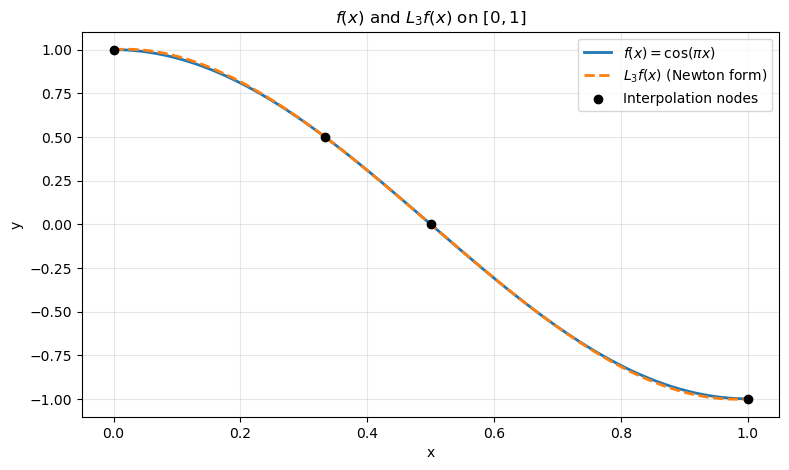

In [42]:
# point c)
# Plot f(x)=cos(pi*x) and L3f(x) on [0,1]

x_plot = np.linspace(0.0, 1.0, 1000)
f_plot = np.cos(np.pi * x_plot)
L3_plot = newton_eval(x_plot, nodes, coeffs)

plt.figure(figsize=(9, 5))
plt.plot(x_plot, f_plot, label=r"$f(x)=\cos(\pi x)$", linewidth=2)
plt.plot(x_plot, L3_plot, "--", label=r"$L_3f(x)$ (Newton form)", linewidth=2)
plt.scatter(nodes, [f(xi) for xi in nodes], color="black", zorder=3, label="Interpolation nodes")

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$f(x)$ and $L_3f(x)$ on $[0,1]$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
# point d)
# Use L3f to approximate cos(pi/5)

x0 = 1.0 / 5.0 # because we have cos(pi*x) and to get pi/5 we will need x0 = 1/5
L3_at_x0 = newton_eval(x0, nodes, coeffs)
true_value = np.cos(np.pi / 5.0)
abs_error = abs(true_value - L3_at_x0)

print(f"x0 = 1/5 = {x0:.6f}")
print(f"L3f(1/5) approximation: {L3_at_x0:.6f}")
print(f"cos(pi/5) true value:   {true_value:.6f}")
print(f"absolute error:         {abs_error:.6f}")


x0 = 1/5 = 0.200000
L3f(1/5) approximation: 0.816000
cos(pi/5) true value:   0.809017
absolute error:         0.006983


In [48]:
# point e)
# Numerical bound for the error of the approximation from point d,
# using only sampled pointwise differences (no derivatives).

x0 = 1.0 / 5.0
f = lambda x: np.cos(np.pi * x)
nodes = np.array([0.0, 1.0 / 3.0, 1.0 / 2.0, 1.0])
coeffs = newton_coefficients(nodes, f=f)

# Actual pointwise error at x0 (same approximation as point d)
actual_err = abs(f(x0) - newton_eval(x0, nodes, coeffs))

# Numerical bound: max sampled error on [0,1]
N = 1000
x_grid = np.linspace(0.0, 1.0, N)
abs_err_grid = np.abs(np.cos(np.pi * x_grid) - newton_eval(x_grid, nodes, coeffs))
bound_e = float(np.max(abs_err_grid))
x_bound = float(x_grid[int(np.argmax(abs_err_grid))])

print(f"x0 = 1/5 = {x0:.12f}")
print(f"Actual error at x0:               {actual_err:.12e}")
print(f"Numerical bound on [0,1] (N={N}): {bound_e:.12e}")
print(f"x where bound is attained (grid): {x_bound:.12f}")
print(f"Bound >= actual error?            {bound_e >= actual_err}")


x0 = 1/5 = 0.200000000000
Actual error at x0:               6.983005625052e-03
Numerical bound on [0,1] (N=1000): 1.095560592199e-02
x where bound is attained (grid): 0.104104104104
Bound >= actual error?            True


### exercise 2

2. Approximate $\sqrt{2}$ using Aitken's algorithm to interpolate the function
$ f(x)=2^x $ at 9 equidistant nodes on the interval $[-4,4]$.  
Use $\varepsilon = 0.001$ as stopping criterion.

In [47]:
# solution
# Approximate sqrt(2) by interpolating f(x)=2^x at x=0.5 (since 2^(1/2)=sqrt(2))
# with Aitken-Neville recursion on 9 equidistant nodes in [-4,4].

import math


def aitken_neville_value(x_nodes, y_nodes, x_eval):
    """Return interpolation value P(x_eval) using Aitken-Neville recursion."""
    x_nodes = np.asarray(x_nodes, dtype=float)
    p = np.asarray(y_nodes, dtype=float).copy()
    n = len(x_nodes)

    for j in range(1, n):
        for i in range(n - j):
            p[i] = ((x_eval - x_nodes[i + j]) * p[i] + (x_nodes[i] - x_eval) * p[i + 1]) / (x_nodes[i] - x_nodes[i + j])
    return float(p[0])


# Data
f = lambda x: 2.0 ** x
x_nodes = np.linspace(-4.0, 4.0, 9)  # 9 equidistant nodes: -4,-3,...,4
y_nodes = f(x_nodes)
x_eval = 0.5
epsilon = 1e-3

# Progressive Aitken approximations using first k nodes
records = []
prev = None
approx = None
used_nodes = len(x_nodes)
stop_refinement_iterations = None  # refinement iterations = used_nodes - 1

for k in range(1, len(x_nodes) + 1):
    approx = aitken_neville_value(x_nodes[:k], y_nodes[:k], x_eval)
    diff = np.nan if prev is None else abs(approx - prev)

    records.append({
        "k_nodes": k,
        "P_k(0.5)": approx,
        "|P_k-P_{k-1}|": diff,
    })

    if prev is not None and diff < epsilon:
        used_nodes = k
        stop_refinement_iterations = k - 1
        break

    prev = approx

if stop_refinement_iterations is None:
    stop_refinement_iterations = len(x_nodes) - 1

results_df = pd.DataFrame(records)
display(results_df)

true_value = math.sqrt(2.0)
actual_error = abs(approx - true_value)

print(f"x for sqrt(2): {x_eval}")
print(f"epsilon: {epsilon}")
print(f"Aitken approximation: {approx:.12f}")
print(f"true sqrt(2):         {true_value:.12f}")
print(f"absolute error:       {actual_error:.12e}")
print(f"nodes used:           {used_nodes}")
print(f"refinement iterations: {stop_refinement_iterations}")

# For this setup and epsilon=0.001, refinement iterations should be 7.


,k_nodes,P_k(0.5),|P_k-P_{k-1}|
0,1,0.062500,NaN
1,2,0.343750,0.281250
2,3,0.835938,0.492188
3,4,1.246094,0.410156
4,5,1.399902,0.153809
5,6,1.415283,0.015381
6,7,1.414001,0.001282
7,8,1.414276,0.000275


x for sqrt(2): 0.5
epsilon: 0.001
Aitken approximation: 1.414276123047
true sqrt(2):         1.414213562373
absolute error:       6.256067377985e-05
nodes used:           8
refinement iterations: 7
